<a href="https://colab.research.google.com/github/sarina2668/sarina2668-Sarina_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [12]:
#Please write the code here
import pandas as pd
from google.colab import files

import sklearn

uploaded=files.upload()
df= pd.read_csv("car_purchase_data.csv")
print(df.head())
print(df.dtypes)

Saving car_purchase_data.csv to car_purchase_data (9).csv
    User ID  Gender  Age  Salary  Purchased
0  15624510    Male   19   19000          0
1  15810944    Male   35   20000          0
2  15668575  Female   26   43000          0
3  15603246  Female   27   57000          0
4  15804002    Male   19   76000          0
User ID       int64
Gender       object
Age           int64
Salary        int64
Purchased     int64
dtype: object


### Step 2: Split features and target

In [15]:
#Please write the code here
X= df[["Age","Salary"]]
y=df["Purchased"]

### Step 3: Train/Test Split

In [22]:
#Please write the code here

#training data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
   X,y,
   test_size=0.3,
   random_state=10,
   shuffle=True
)

### Step 4: Feature Scaling

In [23]:
#Please write the code here
from sklearn.preprocessing import StandardScaler
scale= StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

### Step 5: Train Logistic Regression Model

In [24]:
#Please write the code here
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, C=0.5)
model.fit(X_train, y_train)

LogisticRegression(C=0.5, max_iter=1000)

### Step 6: Predict and Evaluate

In [25]:
#Please write the code here
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.875


In [28]:
print(df['Age'].min())
print(df['Salary'].min())

print(df['Age'].max())
print(df['Salary'].max())

18
15000
60
150000


### Step 7: Visualization of Decision Regions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


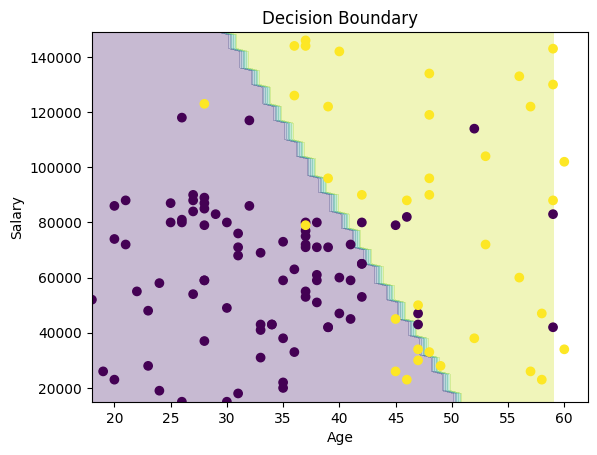

In [31]:
#Please write the code here

import numpy as np
import matplotlib.pyplot as plt



X1, X2 = np.meshgrid(
    np.arange(start=18, stop=60, step=1),
    np.arange(start=15000, stop=150000, step=1000)
)


grid = np.array([X1.ravel(), X2.ravel()]).T
grid_scaled = scale.transform(grid)


Z = model.predict(grid_scaled)
Z = Z.reshape(X1.shape)


plt.contourf(X1, X2, Z, alpha=0.3)


X_test_original = scale.inverse_transform(X_test)


plt.scatter(X_test_original[:, 0], X_test_original[:, 1], c=y_test)


plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Decision Boundary")

plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1: Logistic regression outputs probabilities — why can it still be used for classification? A: Logistic regression predicts the probability of how likely a customer is to purchase a car (from 0 to 1). If the probability is greater than or equal to 0.5, the model class predicts "purchase."

2: Based on your model, which customers are more likely to purchase a car? A: Customers who are older and have higher salaries are mostly likley to purchase a car

3: What factors might cause low accuracy in this task? A: The dataset might not be diverse enough. There might be noise or inconsistencies in the data. The relationship between features and target may not be completely linear

4: Propose additional features or preprocessing steps that could improve accuracy. A: Customer's credit score or financial stability could be useful. Family size could also dictate whether or not the customer purchases a car.